In [1]:
import pandas as pd

df = pd.read_csv('/Users/kurozuhajime/Desktop/Pythonコード・データ/JSScheduling/data/Benchmark/ft10.csv')

df

,J_N,M_1,P_1,M_2,P_2,M_3,P_3,M_4,P_4,M_5,...,M_6,P_6,M_7,P_7,M_8,P_8,M_9,P_9,M_10,P_10
0,1,1,29,2,78,3,9,4,36,5,...,6,11,7,62,8,56,9,44,10,21
1,2,1,43,3,90,5,75,10,11,4,...,2,28,7,46,6,46,8,72,9,30
2,3,2,91,1,85,4,39,3,74,9,...,6,10,8,12,7,89,10,45,5,33
3,4,2,81,3,95,1,71,5,99,7,...,9,52,8,85,4,98,10,22,6,43
4,5,3,14,1,6,2,22,6,61,4,...,5,69,9,21,8,49,10,72,7,53
5,6,3,84,2,2,6,52,4,95,9,...,10,72,1,47,7,65,5,6,8,25
6,7,2,46,1,37,4,61,3,13,7,...,6,21,10,32,9,89,8,30,5,55
7,8,3,31,1,86,2,46,6,74,5,...,7,88,9,19,10,48,8,36,4,79
8,9,1,76,2,69,4,76,6,51,3,...,10,11,7,40,8,89,5,26,9,74
9,10,2,85,1,13,3,61,7,7,9,...,10,76,6,47,4,52,5,90,8,45


In [2]:
m = 10
n = 10

processtime = {}
machine = {}
for i in range(n):
    for k in range(m):
        idx_M = 'M_' + str(k+1)
        idx_P = 'P_' + str(k+1)
        processtime[(i,k)] = df[idx_P][i]
        machine[(i,k)] = df[idx_M][i]

print(processtime)
print(machine)

{(0, 0): np.int64(29), (0, 1): np.int64(78), (0, 2): np.int64(9), (0, 3): np.int64(36), (0, 4): np.int64(49), (0, 5): np.int64(11), (0, 6): np.int64(62), (0, 7): np.int64(56), (0, 8): np.int64(44), (0, 9): np.int64(21), (1, 0): np.int64(43), (1, 1): np.int64(90), (1, 2): np.int64(75), (1, 3): np.int64(11), (1, 4): np.int64(69), (1, 5): np.int64(28), (1, 6): np.int64(46), (1, 7): np.int64(46), (1, 8): np.int64(72), (1, 9): np.int64(30), (2, 0): np.int64(91), (2, 1): np.int64(85), (2, 2): np.int64(39), (2, 3): np.int64(74), (2, 4): np.int64(90), (2, 5): np.int64(10), (2, 6): np.int64(12), (2, 7): np.int64(89), (2, 8): np.int64(45), (2, 9): np.int64(33), (3, 0): np.int64(81), (3, 1): np.int64(95), (3, 2): np.int64(71), (3, 3): np.int64(99), (3, 4): np.int64(9), (3, 5): np.int64(52), (3, 6): np.int64(85), (3, 7): np.int64(98), (3, 8): np.int64(22), (3, 9): np.int64(43), (4, 0): np.int64(14), (4, 1): np.int64(6), (4, 2): np.int64(22), (4, 3): np.int64(61), (4, 4): np.int64(26), (4, 5): np.i

In [3]:
from pulp import *

I = tuple(range(n))
K = tuple(range(m))

"""
processtime = {(1,1):140, (1,2):40, (1,3):80, \
                (2,1):40, (2,2):100, (2,3):100, \
                (3,1):60, (3,2):160, (3,3):40, \
                (4,1):100, (4,2):80, (4,3):40}
machine = {(1,1):1, (1,2):2, (1,3):3,\
           (2,1):1, (2,2):3, (2,3):2,\
           (3,1):2, (3,2):3, (3,3):1,\
            (4,1):2, (4,2):1, (4,3):3}
"""


M = 100000
s = {}
x = {}

model = LpProblem(sense=LpMinimize)

mkspn = LpVariable('mkspn', lowBound=0, upBound=None, cat='Continuous')

for i in I:
    for k in K:
        s[i,k] = LpVariable(f's[{i},{k}]', lowBound=0, upBound=None, cat='Continuous')

for i in I:
    for k in K:
        for j in I:
            for l in K:
                if (i!=j) & (machine[i,k]==machine[j,l]):
                    x[i,k,j,l] = LpVariable(f'x[{i},{k},{j},{l}]', cat='Binary')

#目的関数
model += mkspn

#制約条件
for i in I:
    for k in K:
        model += mkspn >= s[i,k] + processtime[i,k]
        model += s[i,k] >= 0

for i in I:
    for k in range(len(K)-1):
        model += s[i,k+1] >= s[i,k] + processtime[i,k]

for i in I:
    for k in K:
        for j in I:
            for l in K:
                if (i!=j) & (machine[i,k]==machine[j,l]):
                    model += s[j,l] >= s[i,k] + processtime[i,k] - M * (1 - x[i,k,j,l])
                    model += s[i,k] >= s[j,l] + processtime[j,l] - M * x[i,k,j,l]
                    model += x[i,k,j,l] + x[j,l,i,k] == 1

result = model.solve()
print('Status', LpStatus[result])
print(value(model.objective))


KeyboardInterrupt: 

In [ ]:
for i in I:
    for k in K:
        print(s[i,k], value(s[i,k]))

for i in I:
    for k in K:
        for j in I:
            for l in K:
                if (i!=j) & (machine[i,k]==machine[j,l]):
                    print(x[i,k,j,l], value(x[i,k,j,l]))


s_0,0_ None
s_0,1_ None
s_0,2_ None
s_0,3_ None
s_0,4_ None
s_0,5_ None
s_0,6_ None
s_0,7_ None
s_0,8_ None
s_0,9_ None
s_1,0_ None
s_1,1_ None
s_1,2_ None
s_1,3_ None
s_1,4_ None
s_1,5_ None
s_1,6_ None
s_1,7_ None
s_1,8_ None
s_1,9_ None
s_2,0_ None
s_2,1_ None
s_2,2_ None
s_2,3_ None
s_2,4_ None
s_2,5_ None
s_2,6_ None
s_2,7_ None
s_2,8_ None
s_2,9_ None
s_3,0_ None
s_3,1_ None
s_3,2_ None
s_3,3_ None
s_3,4_ None
s_3,5_ None
s_3,6_ None
s_3,7_ None
s_3,8_ None
s_3,9_ None
s_4,0_ None
s_4,1_ None
s_4,2_ None
s_4,3_ None
s_4,4_ None
s_4,5_ None
s_4,6_ None
s_4,7_ None
s_4,8_ None
s_4,9_ None
s_5,0_ None
s_5,1_ None
s_5,2_ None
s_5,3_ None
s_5,4_ None
s_5,5_ None
s_5,6_ None
s_5,7_ None
s_5,8_ None
s_5,9_ None
s_6,0_ None
s_6,1_ None
s_6,2_ None
s_6,3_ None
s_6,4_ None
s_6,5_ None
s_6,6_ None
s_6,7_ None
s_6,8_ None
s_6,9_ None
s_7,0_ None
s_7,1_ None
s_7,2_ None
s_7,3_ None
s_7,4_ None
s_7,5_ None
s_7,6_ None
s_7,7_ None
s_7,8_ None
s_7,9_ None
s_8,0_ None
s_8,1_ None
s_8,2_ None
s_8,

TypeError: unsupported operand type(s) for +: 'NoneType' and 'int'

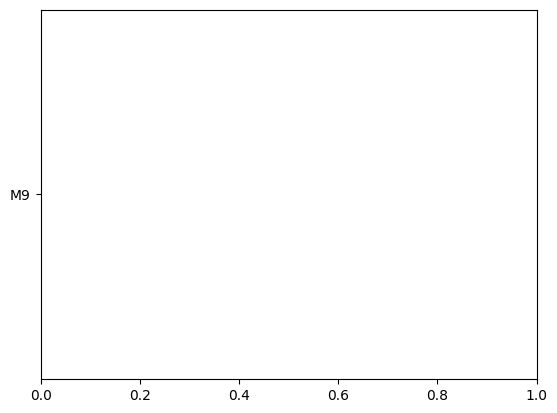

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

fig, ax = plt.subplots()

machine_name = []
start_time = []
process_time = []

for k in K:
    machine_name.append(f'M{k}')
    start_time.append(0)
    process_time.append(0)
machine_name.reverse()

for i in I:
    col = cm.plasma(i*40-40)
    for k in K:
        start_time[machine[i,k]-1] = value(s[i,k])
        process_time[machine[i,k]-1] = processtime[i,k]
        start_time.reverse()
        process_time.reverse()
        ax.barh(machine_name, process_time, left=start_time, color=col)
        start_time.reverse()
        process_time.reverse()
        start_time[machine[i,k]-1]=0
        process_time[machine[i,k]-1] = 0